In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def load_binary_dataset(input_dir, mask_dir):
    images = []
    masks = []
    
    # Find all images in the input directory
    valid_files = [f for f in os.listdir(input_dir) if f.endswith((".png", ".jpg", ".jpeg"))]
    
    for filename in valid_files:
        img_path = os.path.join(input_dir, filename)
        mask_path = os.path.join(mask_dir, filename)
        
        # Only process if both the multicolored image and B&W mask exist
        if not os.path.exists(mask_path):
            continue
            
        # 1. Load Input (Multicolored Map)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (256, 256))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 2. Load Target (Black & White Mask)
        mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_img = cv2.resize(mask_img, (256, 256))
        
        # 3. Convert B&W mask to strictly 0s and 1s
        _, binary_mask = cv2.threshold(mask_img, 127, 1, cv2.THRESH_BINARY)
        binary_mask = np.expand_dims(binary_mask, axis=-1) # Keras expects shape (256, 256, 1)
        
        images.append(img)
        masks.append(binary_mask)
        
    return np.array(images) / 255.0, np.array(masks)

# Define your folders
train_input_dir = os.path.join("flood_dataset", "train")
test_input_dir = os.path.join("flood_dataset", "test")
mask_dir = os.path.join("masks") # Folder holding the B&W masks

print("Loading Training Data...")
X_train, y_train = load_binary_dataset(train_input_dir, mask_dir)

print("Loading Testing Data...")
X_test, y_test = load_binary_dataset(test_input_dir, mask_dir)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")

Loading Training Data...
Loading Testing Data...
X_train shape: (31, 256, 256, 3) | y_train shape: (31, 256, 256, 1)
X_test shape: (10, 256, 256, 3) | y_test shape: (10, 256, 256, 1)


In [5]:
import tensorflow.keras.backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, UpSampling2D
from tensorflow.keras.models import Model

# 1. Define the Custom Dice Metric and Loss
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.cast(K.flatten(y_true), 'float32')
    y_pred_f = K.cast(K.flatten(y_pred), 'float32')
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# 2. Build the Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = UpSampling2D((2, 2))(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

# 1 Output Channel, Sigmoid Activation
predictions = Conv2D(1, (1, 1), activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# CRITICAL CHANGE: Use our custom Dice Loss instead of binary_crossentropy
model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy', dice_coef])

# Train the model
print("Starting Training with Dice Loss...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=8, 
    epochs=15  # Bumped to 15 epochs to give it time to learn the shape
)

Starting Training with Dice Loss...
Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7422 - dice_coef: 0.0907 - loss: 0.9114 - val_accuracy: 0.9375 - val_dice_coef: 0.2100 - val_loss: 0.7834
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9372 - dice_coef: 0.2457 - loss: 0.7548 - val_accuracy: 0.9199 - val_dice_coef: 0.2837 - val_loss: 0.7130
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9277 - dice_coef: 0.2995 - loss: 0.7002 - val_accuracy: 0.9017 - val_dice_coef: 0.2974 - val_loss: 0.7066
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9325 - dice_coef: 0.3279 - loss: 0.6732 - val_accuracy: 0.9473 - val_dice_coef: 0.3713 - val_loss: 0.6175
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9408 - dice_coef: 0.3678 - loss: 0.6316 - val_accuracy: 0.9339 - val_dice_coef: 0.3852 - val_loss: 0.6134
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9441 - dice_coef: 0.3651 - loss: 0.6354 - val_accuracy: 0.9221 - va

--- Evaluating Model on Test Set ---
Test Loss: 0.5288
Test Pixel Accuracy: 95.53%

Generating predictions for IoU calculation...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Test Intersection over Union (IoU): 30.64%

Plotting visual comparison for the first test image...


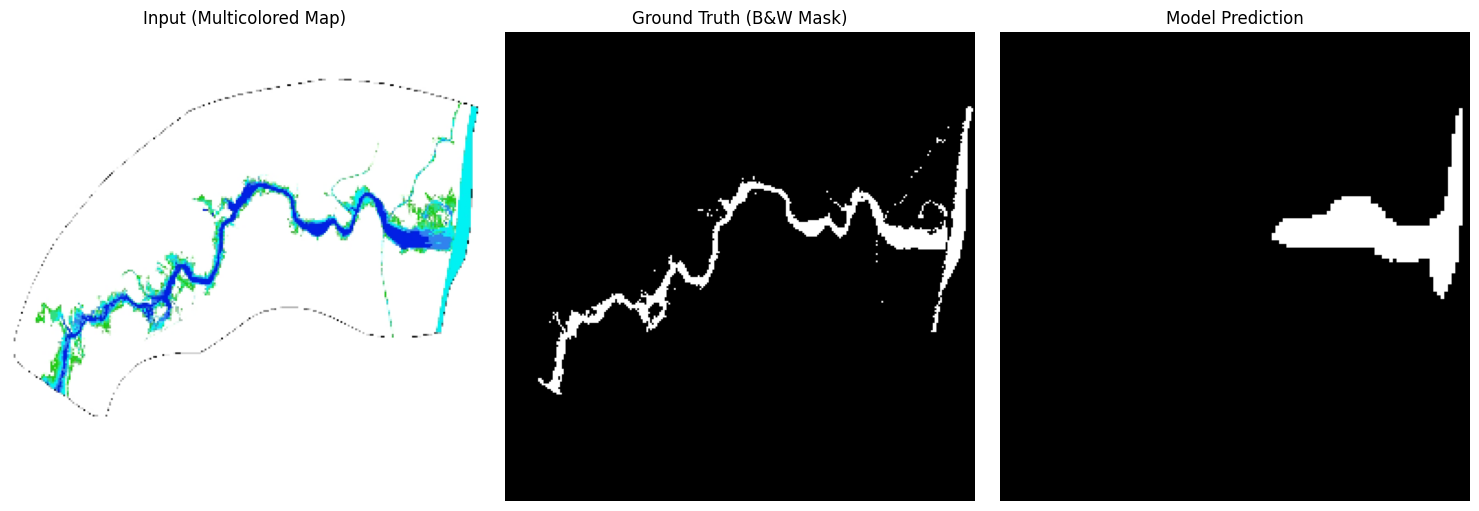

In [6]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Evaluating Model on Test Set ---")

# 1. Standard Keras Evaluation (Loss and Accuracy)
results = model.evaluate(X_test, y_test, batch_size=8, verbose=0)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Pixel Accuracy: {results[1] * 100:.2f}%")

# 2. Predict on the Test Set
print("\nGenerating predictions for IoU calculation...")
y_pred = model.predict(X_test)

# Convert probabilities (sigmoid output) to strict binary (0 or 1) using a 0.5 threshold
y_pred_binary = (y_pred > 0.5).astype(np.uint8)
y_test_binary = y_test.astype(np.uint8)

# 3. Calculate Intersection over Union (IoU) across the whole test set
intersection = np.sum(np.logical_and(y_test_binary, y_pred_binary))
union = np.sum(np.logical_or(y_test_binary, y_pred_binary))

iou_score = (intersection / union) * 100 if union > 0 else 0.0
print(f"Test Intersection over Union (IoU): {iou_score:.2f}%")

# 4. Visual Proof (Plotting the first image in the test set)
print("\nPlotting visual comparison for the first test image...")
plt.figure(figsize=(15, 5))

# Original Input (Multicolored Map)
plt.subplot(1, 3, 1)
plt.title("Input (Multicolored Map)")
plt.imshow(X_test[0])
plt.axis('off')

# Ground Truth (B&W Mask)
plt.subplot(1, 3, 2)
plt.title("Ground Truth (B&W Mask)")
plt.imshow(y_test_binary[0].squeeze(), cmap='gray')
plt.axis('off')

# Model's Prediction
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(y_pred_binary[0].squeeze(), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import tf2onnx

# Input signature matches our 3-channel RGB maps
input_signature = [tf.TensorSpec([None, 256, 256, 3], tf.float32, name='input_image')]
onnx_model_path = "resnet50_flood_binary.onnx"

print("Converting trained model to ONNX...")
model_proto, _ = tf2onnx.convert.from_keras(
    model, 
    input_signature=input_signature, 
    output_path=onnx_model_path
)

print(f"Success! Trained model exported to {onnx_model_path}")

Converting trained model to ONNX...


Success! Trained model exported to resnet50_flood_binary.onnx


In [7]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import time
from tensorflow.keras import layers, Model

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def load_binary_dataset(input_dir, mask_dir, target_size=(256, 256)):
    images = []
    masks = []
    valid_files = [f for f in os.listdir(input_dir) if f.endswith((".png", ".jpg", ".jpeg"))]
    
    print(f"Found {len(valid_files)} potential images. Loading...")
    for filename in valid_files:
        img_path = os.path.join(input_dir, filename)
        mask_path = os.path.join(mask_dir, filename)
        
        if not os.path.exists(mask_path):
            continue
            
        # Load and process input satellite/map image
        img = cv2.imread(img_path)
        img = cv2.resize(img, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Load and process black-and-white ground truth mask
        mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_img = cv2.resize(mask_img, target_size)
        
        # Strictly binarize mask to 0 and 1
        _, binary_mask = cv2.threshold(mask_img, 127, 1, cv2.THRESH_BINARY)
        binary_mask = np.expand_dims(binary_mask, axis=-1)
        
        images.append(img)
        masks.append(binary_mask)
        
    # Change the last return line of Cell 1's loader to this:
    return np.array(images, dtype=np.float32) / 255.0, np.array(masks, dtype=np.float32)

# Define paths matching your local repository layout
train_input_dir = os.path.join("flood_dataset", "train")
mask_dir = os.path.join("masks")

X, y = load_binary_dataset(train_input_dir, mask_dir)
print(f"Dataset loaded successfully!")
print(f"Input Images Shape: {X.shape} | Ground Truth Masks Shape: {y.shape}")

Found 40 potential images. Loading...
Dataset loaded successfully!
Input Images Shape: (31, 256, 256, 3) | Ground Truth Masks Shape: (31, 256, 256, 1)


In [8]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    # CRITICAL FIX: Cast y_true from uint8 to float32 so it matches y_pred
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    # Ensure inputs are float32 for the cross entropy calculation as well
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def dice_coeff(y_true, y_pred):
    return 1.0 - dice_loss(y_true, y_pred)

In [9]:
# 1. Simple CNN Architecture
def build_simple_cnn(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
    return Model(inputs, outputs, name="Simple_CNN")

# 2. FCNN Architecture (Encoder-Decoder without skip connections)
def build_fcnn(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    # Decoder
    x = layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, (2, 2), strides=2, padding='same')(x)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
    return Model(inputs, outputs, name="FCNN")

# 3. U-Net Architecture (Preserving repository structure layout)
def conv_block(x, filters):
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
    x = layers.concatenate([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)
    # Encoder
    c1, p1 = encoder_block(inputs, 32)
    c2, p2 = encoder_block(p1, 64)
    c3, p3 = encoder_block(p2, 128)
    # Bottleneck
    b1 = conv_block(p3, 256)
    # Decoder
    d1 = decoder_block(b1, c3, 128)
    d2 = decoder_block(d1, c2, 64)
    d3 = decoder_block(d2, c1, 32)
    # Final layer adjusted to 1 channel, Sigmoid
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(d3)
    return Model(inputs, outputs, name="U-Net")

In [10]:
# Instantiate all models
models = {
    "Simple_CNN": build_simple_cnn(),
    "FCNN": build_fcnn(),
    "U-Net": build_unet()
}

performance_summary = []
EPOCHS = 30
BATCH_SIZE = 4

for name, model in models.items():
    print(f"\n==========================================")
    print(f" STARTING TRAINING FOR MODEL: {name}")
    print(f"==========================================")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy', dice_coeff]
    )
    
    start_time = time.time()
    history = model.fit(
        X, y,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.2,
        verbose=1
    )
    elapsed_time = time.time() - start_time
    
    # Track metrics from the final epoch
    final_loss = history.history['loss'][-1]
    final_val_dice = history.history['val_dice_coeff'][-1]
    
    performance_summary.append({
        "Model Name": name,
        "Train Loss": round(final_loss, 4),
        "Val Dice (IoU Match)": round(final_val_dice * 100, 2),
        "Training Time (s)": round(elapsed_time, 2)
    })
    
    # Save the native Keras weights right away
    model.save(f"flood_{name.lower()}_model.keras")

# Print out comparisons once everything completes
print(f"\n==========================================")
print(f"         TRAINING RESULTS SUMMARY         ")
print(f"==========================================")
print(pd.DataFrame(performance_summary))


 STARTING TRAINING FOR MODEL: Simple_CNN
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.0434 - dice_coeff: 0.0746 - loss: 1.6732 - val_accuracy: 0.0906 - val_dice_coeff: 0.1013 - val_loss: 1.6019
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.7861 - dice_coeff: 0.0770 - loss: 1.5924 - val_accuracy: 0.9542 - val_dice_coeff: 0.1043 - val_loss: 1.5316
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.9656 - dice_coeff: 0.0794 - loss: 1.5249 - val_accuracy: 0.9580 - val_dice_coeff: 0.1075 - val_loss: 1.4711
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.9650 - dice_coeff: 0.0821 - loss: 1.4674 - val_accuracy: 0.9530 - val_dice_coeff: 0.1108 - val_loss: 1.4191
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.9623 - dice_coeff: 0.0851 - loss: 1.4131 - val_accuracy: 0.9491 - val_dice_coeff: 0.1152 - val_loss: 1.3629
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.9603 - dice_coeff: 0.0890 - loss: 

=================== LOADING TEST DATASET ===================
Found 12 potential images. Loading...
Successfully loaded physical test data!
Test Images: (10, 256, 256, 3) | Test Masks: (10, 256, 256, 1)

=================== QUANTITATIVE PERFORMANCE TEST ===================
[Simple_CNN Model Test Metrics]
  -> Test Loss:      0.3448
  -> Test Accuracy:  0.9878
  -> Mean IoU Score: 0.7296
--------------------------------------------------
[FCNN Model Test Metrics]
  -> Test Loss:      0.4603
  -> Test Accuracy:  0.9754
  -> Mean IoU Score: 0.5158
--------------------------------------------------
[U-Net Model Test Metrics]
  -> Test Loss:      0.1784
  -> Test Accuracy:  0.9895
  -> Mean IoU Score: 0.7809
--------------------------------------------------

=================== VISUAL PREDICTION COMPARISON ===================


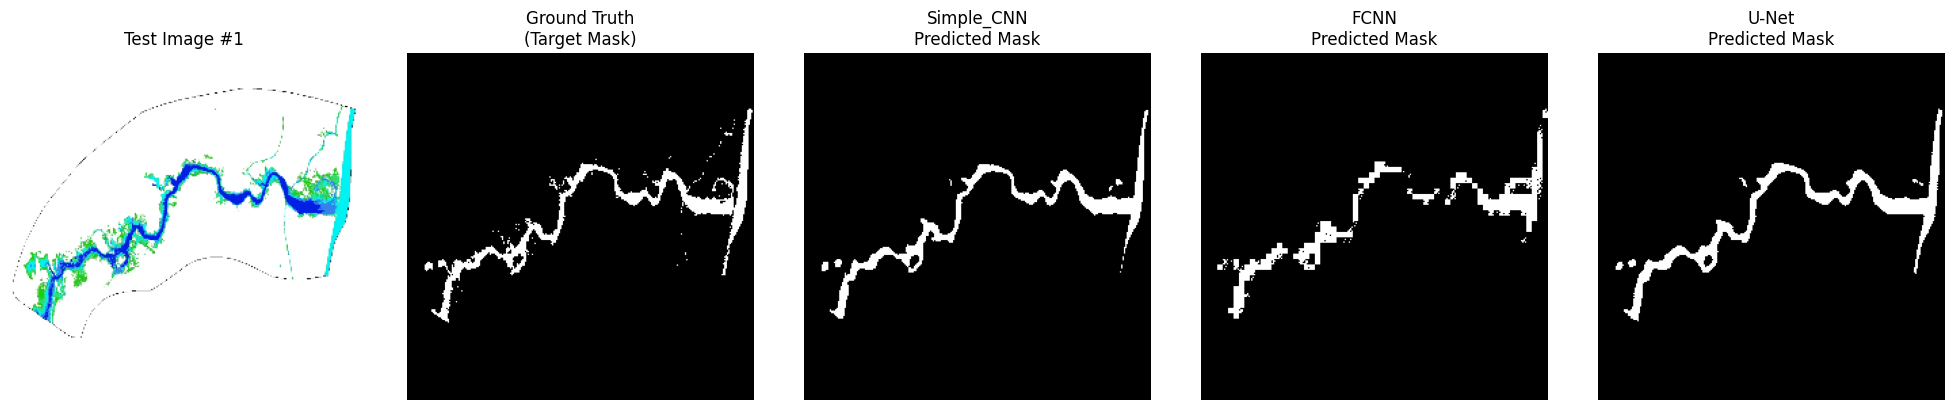

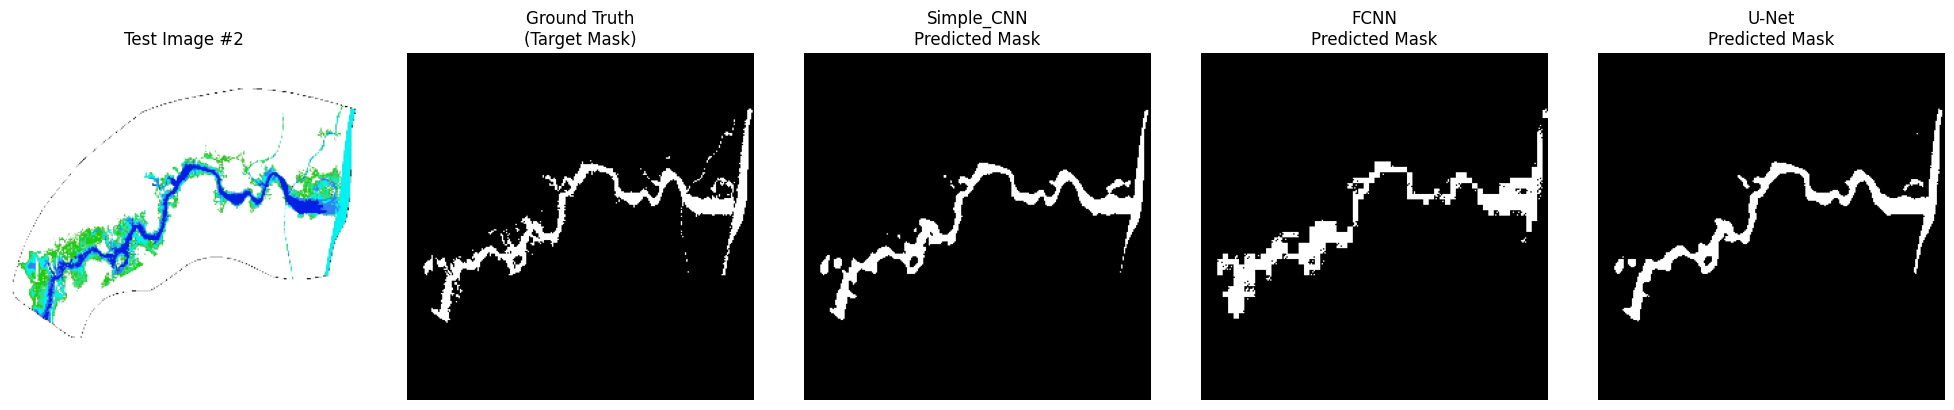

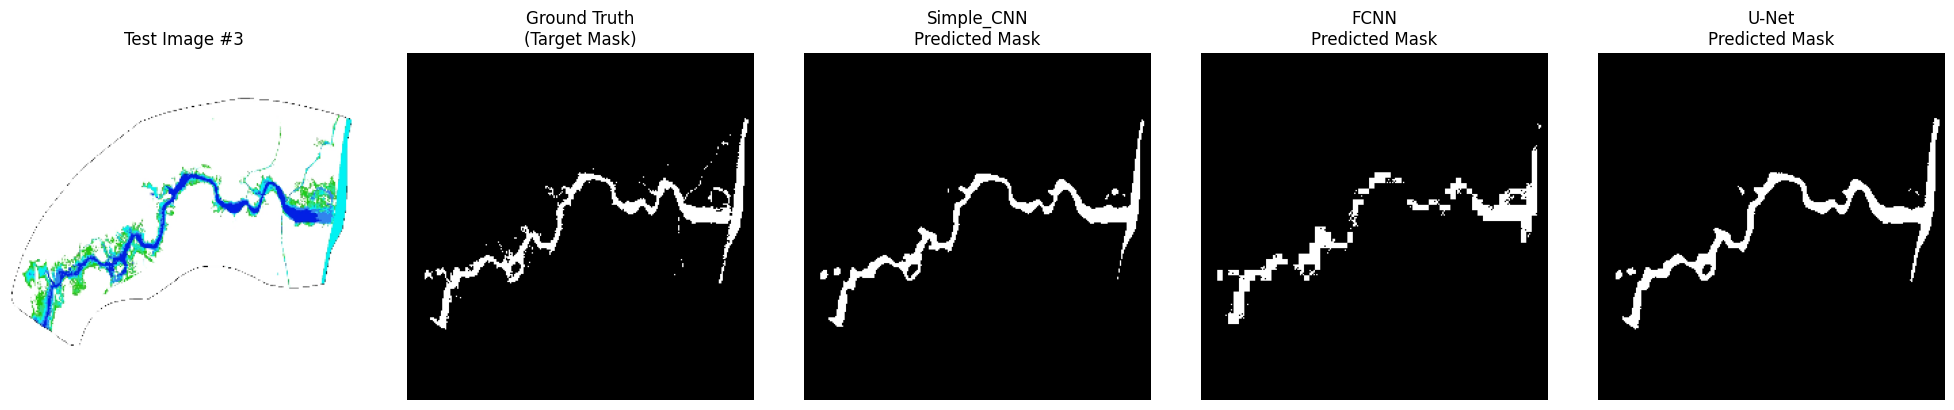

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Actual Test Dataset from its dedicated folder
test_input_dir = os.path.join("flood_dataset", "test")
mask_dir = os.path.join("masks")  # Shared ground truth masks folder

print("=================== LOADING TEST DATASET ===================")
# Reusing the loading logic to fetch test images and corresponding masks
X_test, y_test = load_binary_dataset(test_input_dir, mask_dir)
print(f"Successfully loaded physical test data!")
print(f"Test Images: {X_test.shape} | Test Masks: {y_test.shape}\n")


# 2. Performance Metric: Intersection over Union (IoU)
def compute_iou(y_true, y_pred, threshold=0.5):
    """
    Computes the Intersection over Union (IoU) score for binary segmentation.
    """
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    union = np.sum(y_true) + np.sum(y_pred_bin) - intersection
    return (intersection + 1e-6) / (union + 1e-6)


# 3. Quantitative Test Evaluation Loop
print("=================== QUANTITATIVE PERFORMANCE TEST ===================")
for name, model in models.items():
    # Evaluate using the compiled loss and dice metric on the actual test set
    eval_results = model.evaluate(X_test, y_test, verbose=0)
    
    # Generate predictions across the test images
    test_predictions = model.predict(X_test, verbose=0)
    
    # Calculate Mean IoU across all test samples
    iou_scores = [compute_iou(y_test[i], test_predictions[i]) for i in range(len(X_test))]
    mean_iou = np.mean(iou_scores)
    
    print(f"[{name} Model Test Metrics]")
    print(f"  -> Test Loss:      {eval_results[0]:.4f}")
    print(f"  -> Test Accuracy:  {eval_results[1]:.4f}")
    print(f"  -> Mean IoU Score: {mean_iou:.4f}")
    print("-" * 50)


# 4. Visual Prediction Pipeline
def visualize_test_predictions(models_to_test, test_images, test_masks, num_samples=3):
    """
    Selects sample images from the test set and plots predictions 
    side-by-side alongside the Input image and Ground Truth Mask.
    """
    # Safeguard in case test dataset size is smaller than num_samples
    num_samples = min(num_samples, len(test_images))
    indices = np.random.choice(len(test_images), num_samples, replace=False)
    num_models = len(models_to_test)
    
    for rank, idx in enumerate(indices):
        # Extract the standard RGB image channels for display
        rgb_display = test_images[idx][:, :, :3]
        ground_truth = test_masks[idx].squeeze()
        
        plt.figure(figsize=(4 * (num_models + 2), 4))
        
        # Subplot 1: Actual Test Input Image
        plt.subplot(1, num_models + 2, 1)
        plt.imshow(rgb_display)
        plt.title(f"Test Image #{rank+1}")
        plt.axis('off')
        
        # Subplot 2: Verified B&W Ground Truth Mask
        plt.subplot(1, num_models + 2, 2)
        plt.imshow(ground_truth, cmap='gray')
        plt.title("Ground Truth\n(Target Mask)")
        plt.axis('off')
        
        # Subplots 3+: Dynamically generate and map predictions for each model
        for i, (model_name, trained_model) in enumerate(models_to_test.items()):
            single_input = np.expand_dims(test_images[idx], axis=0)
            raw_prediction = trained_model.predict(single_input, verbose=0)[0]
            
            # Threshold probabilities (>0.5 means water)
            binary_prediction = (raw_prediction > 0.5).astype(np.uint8).squeeze()
            
            plt.subplot(1, num_models + 2, i + 3)
            plt.imshow(binary_prediction, cmap='gray')
            plt.title(f"{model_name}\nPredicted Mask")
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()

# 5. Execute Visualization on the test set
print("\n=================== VISUAL PREDICTION COMPARISON ===================")
visualize_test_predictions(models, X_test, y_test, num_samples=3)

In [13]:
import tf2onnx

# Explicit input signature tracking standard image tensors (Batch, Height, Width, Channels)
input_signature = [tf.TensorSpec([None, 256, 256, 3], tf.float32, name='input_image')]

print("Initiating bulk conversion to ONNX format...\n")

for name, model in models.items():
    onnx_file_name = f"{name.lower()}.onnx"
    print(f"Transforming {name}...")
    
    model_proto, _ = tf2onnx.convert.from_keras(
        model, 
        input_signature=input_signature, 
        output_path=onnx_file_name
    )
    print(f"Successfully saved production-ready model to: {onnx_file_name}\n")

print("All pipeline conversions are fully complete!")

Initiating bulk conversion to ONNX format...

Transforming Simple_CNN...
Successfully saved production-ready model to: simple_cnn.onnx

Transforming FCNN...
Successfully saved production-ready model to: fcnn.onnx

Transforming U-Net...
Successfully saved production-ready model to: u-net.onnx

All pipeline conversions are fully complete!
